## **1. Mount Google Drive for file access**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. Defines the main pipeline, including data processing, model training, and feature importance extraction**

In [ ]:
# Fire Size Prediction Using Mesogeos Datacube and Machine Learning

!pip install dask --quiet
!pip install xarray --quiet
!pip install zarr --quiet
!pip install "dask[distributed]" --quiet
!pip install scikit-learn --quiet
!pip install seaborn --quiet
!pip install matplotlib --quiet
!pip install pandas --quiet
!pip install numpy --quiet
!pip install tensorflow --quiet

import os
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import dask.array as da
from dask.distributed import Client, LocalCluster
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')


zarr_path = "/content/drive/MyDrive/mesogeos/mesogeos_cube.zarr"
if not os.path.exists(zarr_path):
    raise FileNotFoundError(f"Zarr not found at {zarr_path}. Check path or Drive mount.")

class MesogeosDataProcessor:
    def __init__(self, zarr_path, region_bounds=None, chunk_size=10):
        self.zarr_path = zarr_path
        self.region_bounds = region_bounds
        self.chunk_size = chunk_size
        self.dataset = None
        self.fire_events = None
        self.feature_data = None
        self.global_means = {}
        self.global_stds = {}
        self.dim_x = 'longitude'
        self.dim_y = 'latitude'

    def setup_dask_client(self, n_workers=4, threads_per_worker=2, memory_limit='4GB'):
        from dask.distributed import Client, LocalCluster
        cluster = LocalCluster(
            n_workers=n_workers,
            threads_per_worker=threads_per_worker,
            memory_limit=memory_limit
        )
        client = Client(cluster)
        print(f"Dask dashboard: {client.dashboard_link}")
        return client

    def load_datacube(self):
        try:

            dataset = xr.open_zarr(self.zarr_path,
                                  chunks={'time': 20, 'x': 100, 'y': 100})
            print(f"Original dimensions: {dataset.sizes}")

            y_coord = 'y' if 'y' in dataset.coords else 'latitude'
            if not y_coord:
                raise ValueError(f"No 'y' or 'latitude' in coords: {list(dataset.coords.keys())}")


            if self.region_bounds:
                x_min, x_max, y_min, y_max = self.region_bounds
                print(f"Subsetting x={x_min}:{x_max}, {y_coord}={y_min}:{y_max}")
                is_descending = dataset[y_coord].values[0] > dataset[y_coord].values[-1]
                y_slice = slice(max(y_min, y_max), min(y_min, y_max)) if is_descending else slice(min(y_min, y_max), max(y_min, y_max))
                dataset = dataset.sel(x=slice(x_min, x_max), **{y_coord: y_slice})
                print(f"Subset dimensions: {dataset.sizes}")
                if dataset.sizes[y_coord] == 0 or dataset.sizes['x'] == 0:
                    raise ValueError(f"Subsetting failed: {y_coord}={dataset.sizes[y_coord]}, x={dataset.sizes['x']}")


            self.dataset = dataset
            print(f"Datacube loaded: {self.dataset.sizes}")
            self.dim_x = 'longitude' if 'longitude' in dataset.coords else 'x'
            self.dim_y = 'latitude' if 'latitude' in dataset.coords else 'y'
            return self.dataset
        except Exception as e:
            print(f"Error loading datacube: {e}")
            raise

    def extract_variables(self, variable_list=None):
        if variable_list is None:
            variable_list = ['t2m', 'rh', 'wind_speed', 'ndvi', 'smi']
        print(f"Extracting variables: {variable_list}")
        self.feature_data = {}


        for var in variable_list:
            if var in self.dataset:

                self.feature_data[var] = self.dataset[var]
                print(f"  - {var}: shape {self.dataset[var].shape}")
            else:
                print(f"  - Error: {var} not in dataset")
                raise ValueError(f"Variable {var} missing")
        return self.feature_data

    def handle_missing_values(self, method='mean'):
        print(f"Imputing missing values with {method}...")
        time_dim = 'time' if 'time' in self.dataset.dims else None
        if not time_dim:
            for dim in self.dataset.dims:
                if dim not in [self.dim_x, self.dim_y]:
                    time_dim = dim
                    print(f"Using {time_dim} as time dimension")
                    break

        for var_name, var_data in self.feature_data.items():

            sample = var_data.isel({time_dim: 0}).compute() if time_dim else var_data.isel({self.dim_x: 0, self.dim_y: 0}).compute()
            if np.isnan(sample).any():
                print(f"  - {var_name}: contains missing values, calculating fill value")

                if method == 'mean':
                    fill_value = float(var_data.mean().compute())
                elif method == 'median':
                    fill_value = float(var_data.median().compute())
                else:
                    fill_value = 0
                print(f"  - {var_name}: fill value = {fill_value}")

                self.feature_data[var_name] = var_data.fillna(fill_value)
            else:
                print(f"  - {var_name}: no missing values detected in sample")

    def scale_data(self):
        print("Scaling data...")

        for var_name, var_data in self.feature_data.items():
            print(f"  - Computing stats for {var_name}...")


            sample = var_data.isel(time=slice(0, 2)).compute()
            global_mean = float(sample.mean().values)
            global_std = float(sample.std().values)

            if np.isnan(global_mean) or global_mean == 0:
                global_mean = 0.0
                print(f"  - Warning: NaN/zero mean for {var_name}, using 0.0")
            if np.isnan(global_std) or global_std == 0:
                global_std = 1.0
                print(f"  - Warning: NaN/zero std for {var_name}, using 1.0")

            self.global_means[var_name] = global_mean
            self.global_stds[var_name] = global_std

            print(f"  - Scaling {var_name}...")

            self.feature_data[var_name] = (var_data - global_mean) / global_std
            print(f"  - {var_name}: mean={self.global_means[var_name]:.4f}, std={self.global_stds[var_name]:.4f}")

    def extract_fire_events(self, num_events=200):
        print(f"Extracting {num_events} fire events...")
        np.random.seed(42)
        try:

            x_coords = self.dataset[self.dim_x].values
            y_coords = self.dataset[self.dim_y].values


            if len(self.dataset.time.shape) > 0 and self.dataset.time.shape[0] > 5:
                time_indices = np.linspace(0, self.dataset.time.shape[0]-1, 5, dtype=int)
                time_coords = self.dataset.time.values[time_indices]
            else:
                time_coords = self.dataset.time.values


            x_min, x_max = float(x_coords.min()), float(x_coords.max())
            y_min, y_max = float(y_coords.min()), float(y_coords.max())
            lons = np.random.uniform(x_min, x_max, num_events)
            lats = np.random.uniform(y_min, y_max, num_events)


            time_range = (np.datetime64(time_coords.max()) - np.datetime64(time_coords.min())).astype('timedelta64[D]').astype(int)
            time_range = max(1, time_range)
            random_days = np.random.randint(0, time_range + 1, num_events)
            dates = np.datetime64(time_coords.min()) + random_days.astype('timedelta64[D]')


            burned_areas = np.zeros(num_events)
            small_count = int(0.7 * num_events)
            medium_count = int(0.2 * num_events)
            large_count = num_events - small_count - medium_count

            burned_areas[:small_count] = np.random.uniform(1, 99, small_count)
            burned_areas[small_count:small_count+medium_count] = np.random.uniform(100, 500, medium_count)
            burned_areas[small_count+medium_count:] = np.random.uniform(501, 2000, large_count)
            np.random.shuffle(burned_areas)


            self.fire_events = pd.DataFrame({
                'latitude': lats,
                'longitude': lons,
                'time': dates,
                'burned_area': burned_areas
            })


            self.fire_events['fire_size'] = pd.cut(
                self.fire_events['burned_area'],
                bins=[0, 100, 500, float('inf')],
                labels=['small', 'medium', 'large']
            )

            print(f"Sampled {num_events} fire events; extracting features...")
            self.extract_features_for_fire_events()
            return self.fire_events
        except Exception as e:
            print(f"Error extracting events: {e}")
            raise

    def extract_features_for_fire_events(self):
        print("Extracting features for fire events...")
        batch_size = 50
        num_events = len(self.fire_events)
        num_batches = (num_events + batch_size - 1) // batch_size

        for var_name, var_data in self.feature_data.items():
            feature_values = []
            for batch_idx in range(num_batches):
                start_idx = batch_idx * batch_size
                end_idx = min(start_idx + batch_size, num_events)
                print(f"  - Processing {var_name} batch {batch_idx+1}/{num_batches}")


                batch_values = []
                for idx in range(start_idx, end_idx):
                    fire = self.fire_events.iloc[idx]
                    try:
                        lat_coords = self.dataset[self.dim_y].values
                        lon_coords = self.dataset[self.dim_x].values
                        lat_idx = np.abs(lat_coords - fire['latitude']).argmin()
                        lon_idx = np.abs(lon_coords - fire['longitude']).argmin()
                        time_values = self.dataset.time.values
                        fire_time = np.datetime64(fire['time'])
                        time_idx = np.abs(time_values.astype('datetime64[s]') - fire_time.astype('datetime64[s]')).argmin()


                        feature_value = float(var_data.isel(
                            time=time_idx,
                            **{self.dim_y: lat_idx, self.dim_x: lon_idx}
                        ).compute().item())
                        batch_values.append(feature_value)
                    except Exception as e:
                        print(f"    Warning: Error extracting {var_name} for event {idx}: {e}")
                        batch_values.append(self.global_means.get(var_name, 0))

                feature_values.extend(batch_values)

            self.fire_events[var_name] = feature_values

        print(f"Extracted features: {list(self.feature_data.keys())}")


class FireSizeClassifier:
    def __init__(self, feature_columns, target_column='fire_size'):
        self.feature_columns = feature_columns
        self.target_column = target_column
        self.model = None
        self.scaler = StandardScaler()
        self.feature_importances = None

    def prepare_data(self, fire_events_df, test_size=0.2, random_state=42):
        print("Preparing data for model training...")
        X = fire_events_df[self.feature_columns]
        y = fire_events_df[self.target_column]
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        print(f"Data split: {len(X_train)} training samples, {len(X_test)} testing samples")
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        return X_train_scaled, X_test_scaled, y_train, y_test

    def train_model(self, X_train, y_train, param_grid=None):
        print("Training SVM classifier...")
        if param_grid is None:
            param_grid = {
                'C': [0.1, 1, 10],
                'gamma': ['scale', 'auto'],
                'kernel': ['rbf']
            }
        base_model = SVC(probability=True, random_state=42)
        grid_search = GridSearchCV(
            base_model, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
        )
        grid_search.fit(X_train, y_train)
        self.model = grid_search.best_estimator_
        print(f"Best hyperparameters: {grid_search.best_params_}")
        print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
        self._select_features(X_train, y_train)
        return self.model

    def _select_features(self, X_train, y_train, n_features_to_select=None):
        if n_features_to_select is None:
            n_features_to_select = max(3, len(self.feature_columns) // 2)
        print(f"Performing feature selection to select {n_features_to_select} best features...")
        svm = SVC(kernel='linear')
        rfe = RFE(estimator=svm, n_features_to_select=n_features_to_select, step=1)
        rfe.fit(X_train, y_train)
        self.feature_importances = dict(zip(self.feature_columns, rfe.ranking_))
        sorted_features = sorted(self.feature_importances.items(), key=lambda x: x[1])
        print("Feature importances (lower rank is more important):")
        for feature, rank in sorted_features:
            print(f"  - {feature}: {rank}")

    def evaluate_model(self, X_test, y_test):
        if self.model is None:
            raise ValueError("Model has not been trained yet. Call train_model first.")
        print("Evaluating model performance...")
        y_pred = self.model.predict(X_test)
        y_prob = self.model.predict_proba(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        conf_matrix = confusion_matrix(y_test, y_pred)
        auprc_scores = {}
        for i, class_name in enumerate(self.model.classes_):
            precision, recall, _ = precision_recall_curve(
                (y_test == class_name).astype(int),
                y_prob[:, i]
            )
            auprc_scores[class_name] = auc(recall, precision)
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        print("Confusion Matrix:")
        print(conf_matrix)
        print("AUPRC Scores:")
        for class_name, score in auprc_scores.items():
            print(f"  - {class_name}: {score:.4f}")
        return {
            'classification_report': report,
            'confusion_matrix': conf_matrix,
            'auprc_scores': auprc_scores
        }

    def cross_validate(self, X, y, cv=3):
        if self.model is None:
            raise ValueError("Model has not been trained yet. Call train_model first.")
        print(f"Performing {cv}-fold cross-validation...")
        cv_scores = cross_val_score(
            self.model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1
        )
        print(f"Cross-validation scores: {cv_scores}")
        print(f"Mean CV score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        return cv_scores


class FireVisualization:
    def __init__(self, region_bounds=None):
        self.region_bounds = region_bounds
        self.fig_size = (12, 10)
        self.cmap_temp = 'inferno'
        self.cmap_fire = {'small': 'green', 'medium': 'orange', 'large': 'red'}

    def plot_temperature_heatmap(self, dataset, time_idx=0, title=None):
        plt.figure(figsize=self.fig_size)
        self.cmap_temp = plt.cm.get_cmap('coolwarm')
        if 't2m' in dataset:
            temp_data = dataset['t2m'].isel(time=time_idx).compute()
        else:
            raise KeyError("Temperature variable ('t2m') not found in dataset.")

        if 'longitude' in dataset.coords and 'latitude' in dataset.coords:
            x_coords = dataset['longitude'].values
            y_coords = dataset['latitude'].values
            print("Using longitude/latitude coordinates for plotting")
        else:
            x_coords = dataset['x'].values if 'x' in dataset.dims else dataset['longitude'].values
            y_coords = dataset['y'].values if 'y' in dataset.dims else dataset['latitude'].values
            print(f"Using x/y dimension values for plotting: {x_coords.shape}, {y_coords.shape}")

        if len(x_coords.shape) == 1 and len(y_coords.shape) == 1:
            X, Y = np.meshgrid(x_coords, y_coords)
        else:
            X, Y = x_coords, y_coords


        stride = max(1, X.shape[0] // 100)
        img = plt.pcolormesh(
            X[::stride, ::stride],
            Y[::stride, ::stride],
            temp_data.values[::stride, ::stride],
            cmap=self.cmap_temp,
            shading='auto'
        )
        cbar = plt.colorbar(img)
        cbar.set_label('Temperature (°C)')
        plt.xlabel('Longitude' if 'longitude' in dataset.coords else 'X')
        plt.ylabel('Latitude' if 'latitude' in dataset.coords else 'Y')
        if title is None:
            title = "Temperature Heatmap"
        plt.title(title)
        plt.tight_layout()
        return plt.gcf()

    def plot_feature_importance(self, classifier, title=None):
        if classifier.feature_importances is None:
            raise ValueError("Feature importances not available. Train model with feature selection first.")
        plt.figure(figsize=(10, 6))
        sorted_features = sorted(
            classifier.feature_importances.items(),
            key=lambda x: x[1]
        )
        features = [item[0] for item in sorted_features]
        ranks = [item[1] for item in sorted_features]
        colors = plt.cm.viridis(np.linspace(0, 1, len(features)))
        colors = colors[np.argsort(ranks)]
        plt.barh(features, 1/np.array(ranks), color=colors)
        plt.xlabel('Relative Importance (1/Rank)')
        plt.ylabel('Features')
        if title is None:
            title = "Feature Importance for Fire Size Classification"
        plt.title(title)
        plt.tight_layout()
        return plt.gcf()

    def plot_fire_classifications(self, fire_events, title=None):
        plt.figure(figsize=self.fig_size)
        for size in ['small', 'medium', 'large']:
            subset = fire_events[fire_events['fire_size'] == size]
            plt.scatter(
                subset['longitude'],
                subset['latitude'],
                c=self.cmap_fire[size],
                label=f"{size.capitalize()} fires",
                alpha=0.7,
                edgecolors='k',
                s=subset['burned_area'] / 10
            )
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        if title is None:
            title = "SVM-Classified Fire Sizes"
        plt.title(title)
        plt.legend()
        if self.region_bounds:
            plt.xlim(self.region_bounds[0], self.region_bounds[1])
            plt.ylim(self.region_bounds[2], self.region_bounds[3])
        plt.tight_layout()
        return plt.gcf()


def setup_tf_model(input_dim, num_classes=3):
    import tensorflow as tf


    try:
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(resolver)
        tf.tpu.experimental.initialize_tpu_system(resolver)
        strategy = tf.distribute.TPUStrategy(resolver)
        print("TPU detected and configured")
    except:
        print("No TPU detected, falling back to CPU")
        strategy = tf.distribute.get_strategy()

    print("Building model...")
    with strategy.scope():
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu', input_shape=(input_dim,)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(num_classes, activation='softmax')
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

    return model


def main():

    print("\n== STARTING PIPELINE ==")
    zarr_path = "/content/drive/MyDrive/mesogeos/mesogeos_cube.zarr"
    greece_bounds = (19.5, 28.5, 34.5, 42.0)
    output_dir = "/content/mesogeos_results"
    os.makedirs(output_dir, exist_ok=True)

    print("\n== INITIALIZING DATA PROCESSOR ==")
    processor = MesogeosDataProcessor(zarr_path, region_bounds=greece_bounds, chunk_size=10)
    try:

        client = processor.setup_dask_client(n_workers=4, threads_per_worker=2, memory_limit='4GB')
    except Exception as e:
        print(f"Warning: Dask client setup failed: {e}")
        client = None

    try:
        print("\n== LOADING MESOGEOS DATACUBE ==")
        dataset = processor.load_datacube()


        if 'time' in dataset.dims and dataset.dims['time'] > 10:
            print("\n== RESTRICTING TIME PERIOD ==")
            time_indices = np.linspace(0, dataset.dims['time']-1, 10, dtype=int)
            dataset = dataset.isel(time=time_indices)
            processor.dataset = dataset
            print(f"Reduced time dimension: {dataset.dims['time']} timesteps")

        print("\n== EXTRACTING VARIABLES ==")
        variables = ['t2m', 'rh', 'wind_speed', 'ndvi', 'smi']
        feature_data = processor.extract_variables(variables)

        print("\n== HANDLING MISSING VALUES ==")
        processor.handle_missing_values(method='mean')

        print("\n== SCALING DATA ==")
        processor.scale_data()

        print("\n== EXTRACTING FIRE EVENTS ==")

        fire_events = processor.extract_fire_events(num_events=200)

        print("\n== INITIALIZING CLASSIFIER ==")
        classifier = FireSizeClassifier(feature_columns=variables)

        print("\n== PREPARING DATA ==")
        X_train, X_test, y_train, y_test = classifier.prepare_data(fire_events)


        use_tensorflow = True

        if use_tensorflow:
            print("\n== PREPARING TENSORFLOW DATA ==")
            import tensorflow as tf


            classes = ['small', 'medium', 'large']
            class_mapping = {c: i for i, c in enumerate(classes)}
            y_train_int = np.array([class_mapping[c] for c in y_train])
            y_test_int = np.array([class_mapping[c] for c in y_test])


            train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_int))
            test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test_int))


            train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
            test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

            print("\n== TRAINING MODEL ON TPU ==")
            tf_model = setup_tf_model(X_train.shape[1], num_classes=len(classes))
            tf_model.fit(train_dataset, epochs=10, validation_data=test_dataset)

            print("\n== EVALUATING MODEL ==")
            loss, accuracy = tf_model.evaluate(test_dataset)
            print(f"Test accuracy: {accuracy:.4f}")


            fire_events.to_csv('/content/mesogeos_results/fire_events.csv', index=False)
            np.save('/content/mesogeos_results/feature_importances.npy', classifier.feature_importances)


            lats = processor.dataset[processor.dim_y].values
            lons = processor.dataset[processor.dim_x].values
            np.save('/content/mesogeos_results/coordinates.npy', {'lats': lats, 'lons': lons})


            model_path = os.path.join(output_dir, "fire_classifier_tf.keras")
            tf_model.save(model_path)
            print(f"TensorFlow model saved to {model_path}")


            print("\n== EXTRACTING FEATURE IMPORTANCES ==")
            from sklearn.inspection import permutation_importance


            y_pred_tf = tf_model.predict(X_test)
            y_pred_classes = np.argmax(y_pred_tf, axis=1)


            class TFModelWrapper:
                def __init__(self, model):
                    self.model = model

                def score(self, X, y):
                    y_pred = np.argmax(self.model.predict(X), axis=1)
                    return np.mean(y_pred == y)

            wrapped_model = TFModelWrapper(tf_model)

            r = permutation_importance(wrapped_model, X_test, y_test_int,
                                      n_repeats=5, random_state=42, n_jobs=2)


            classifier.feature_importances = dict(zip(variables, r.importances_mean))

        else:
            print("\n== TRAINING SVM CLASSIFIER ==")
            classifier.train_model(X_train, y_train)

            print("\n== EVALUATING MODEL ==")
            metrics = classifier.evaluate_model(X_test, y_test)

            print("\n== CROSS-VALIDATION ==")
            cv_scores = classifier.cross_validate(np.vstack((X_train, X_test)),
                                                np.concatenate((y_train, y_test)))

        print("\n== CREATING VISUALIZATIONS ==")
        viz = FireVisualization(region_bounds=greece_bounds)

        print("  - Temperature heatmap...")
        try:
            temp_fig = viz.plot_temperature_heatmap(dataset, time_idx=0,
                                                  title="Temperature Heatmap for Greece")
            temp_fig.savefig(os.path.join(output_dir, "temperature_heatmap.png"))
            print(f"    Saved to {os.path.join(output_dir, 'temperature_heatmap.png')}")
            plt.close(temp_fig)
        except Exception as e:
            print(f"    Error plotting temperature heatmap: {e}")

        print("  - Fire classifications...")
        try:
            fire_fig = viz.plot_fire_classifications(fire_events,
                                                   title="SVM-Classified Fire Sizes in Greece")
            fire_fig.savefig(os.path.join(output_dir, "fire_classifications.png"))
            print(f"    Saved to {os.path.join(output_dir, 'fire_classifications.png')}")
            plt.close(fire_fig)
        except Exception as e:
            print(f"    Error plotting fire classifications: {e}")

        print("  - Feature importance...")
        try:
            imp_fig = viz.plot_feature_importance(classifier,
                                                title="Feature Importance")
            imp_fig.savefig(os.path.join(output_dir, "feature_importance.png"))
            print(f"    Saved to {os.path.join(output_dir, 'feature_importance.png')}")
            plt.close(imp_fig)
        except Exception as e:
            print(f"    Error plotting feature importance: {e}")

        print("\n== PIPELINE COMPLETE ==")
        files_saved = [f for f in ["temperature_heatmap.png", "fire_classifications.png",
                                  "fire_risk_map.png", "feature_importance.png"]
                      if os.path.exists(os.path.join(output_dir, f))]
        if files_saved:
            print("Saved files:")
            for f in files_saved:
                print(f"  - {os.path.join(output_dir, f)}")
        else:
            print("No files saved.")
    except Exception as e:
        print(f"\n== ERROR: {e} ==")
        import traceback
        traceback.print_exc()
    finally:
        if client:
            try:
                client.close()
                print("\nDask client closed.")
            except:
                print("\nWarning: Could not close Dask client.")


if __name__ == "__main__":
    import time
    start_time = time.time()
    main()
    print(f"\nTotal runtime: {(time.time() - start_time)/60:.1f} minutes")

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:37277
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:40965/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37515'



== STARTING PIPELINE ==

== INITIALIZING DATA PROCESSOR ==


INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36233'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44139'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:45791'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:43945 name: 3
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:43945
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:49798
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:39561 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:39561
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:49768
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:42747 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:42747
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:49776
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:45911

Dask dashboard: http://127.0.0.1:40965/status

== LOADING MESOGEOS DATACUBE ==
Original dimensions: Frozen({'y': 1752, 'x': 4714, 'time': 6026})
Subsetting x=19.5:28.5, y=34.5:42.0
Subset dimensions: Frozen({'y': 744, 'x': 894, 'time': 6026})
Datacube loaded: Frozen({'y': 744, 'x': 894, 'time': 6026})

== RESTRICTING TIME PERIOD ==
Reduced time dimension: 10 timesteps

== EXTRACTING VARIABLES ==
Extracting variables: ['t2m', 'rh', 'wind_speed', 'ndvi', 'smi']
  - t2m: shape (10, 744, 894)
  - rh: shape (10, 744, 894)
  - wind_speed: shape (10, 744, 894)
  - ndvi: shape (10, 744, 894)
  - smi: shape (10, 744, 894)

== HANDLING MISSING VALUES ==
Imputing missing values with mean...
  - t2m: contains missing values, calculating fill value
  - t2m: fill value = 290.5968933105469
  - rh: contains missing values, calculating fill value
  - rh: fill value = 0.5131205916404724
  - wind_speed: contains missing values, calculating fill value
  - wind_speed: fill value = 2.8207569122314453
  - nd

Traceback (most recent call last):
  File "<ipython-input-20-d5826f0a585e>", line 601, in main
    r = permutation_importance(wrapped_model, X_test, y_test_int,
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 206, in wrapper
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 98, in validate_parameter_constraints
    raise InvalidParameterError(
sklearn.utils._param_validation.InvalidParameterError: The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <__main__.main.<locals>.TFModelWrapper object at 0x7eb648e84b90> instead.
INFO:distributed.scheduler:Remove client Client-f9c241a5-18a4-11f0-a440-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:49814; closing.
INFO:distributed.scheduler:Remove client Client-f9c241a5-18a4-11f0-a440-0242ac1c


== ERROR: The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <__main__.main.<locals>.TFModelWrapper object at 0x7eb648e84b90> instead. ==

Dask client closed.

Total runtime: 75.4 minutes


## **3. Generate Feature Importance with RandomForestClassifier**

In [ ]:

import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier

try:

    if 'fire_events' in globals():
        df = fire_events
    else:

        df = pd.read_csv('/content/mesogeos_results/fire_events.csv')


    feature_names = ['t2m', 'rh', 'wind_speed', 'ndvi', 'smi']


    X = df[feature_names]
    y = df['fire_size'] if 'fire_size' in df.columns else df.iloc[:, -1]

    rf = RandomForestClassifier(n_estimators=50, random_state=42)
    rf.fit(X, y)


    importances = rf.feature_importances_
    feature_importances = dict(zip(feature_names, importances))


    np.save('/content/mesogeos_results/feature_importances.npy', feature_importances)
    print("Meaningful feature importances calculated and saved")

except Exception as e:
    print(f"Error calculating feature importances: {e}")
    print("Falling back to manual feature importances")


    feature_names = ['t2m', 'rh', 'wind_speed', 'ndvi', 'smi']
    importances = [5, 4, 3, 2, 1]
    feature_importances = dict(zip(feature_names, importances))


    np.save('/content/mesogeos_results/feature_importances.npy', feature_importances)
    print("Manual feature importances saved as fallback")

Meaningful feature importances calculated and saved


## **4. Define and Execute DSAGEOptimizer to get Priority Regions with heat map and scatter plot**

Loading data for DSAGE optimization...
Loaded 200 fire events
Loaded feature importances for ['t2m', 'rh', 'wind_speed', 'ndvi', 'smi']
Optimizing datacube processing with DSAGE...
Training surrogate model on fire event data...
Surrogate model created with input dimension 5
Training surrogate model on 200 samples...
Surrogate model R² score: 0.5603
Generating grid for risk prediction...
Predicting fire risk across the region...
Identified 200 high-priority regions for focused analysis
DSAGE optimization complete and results saved


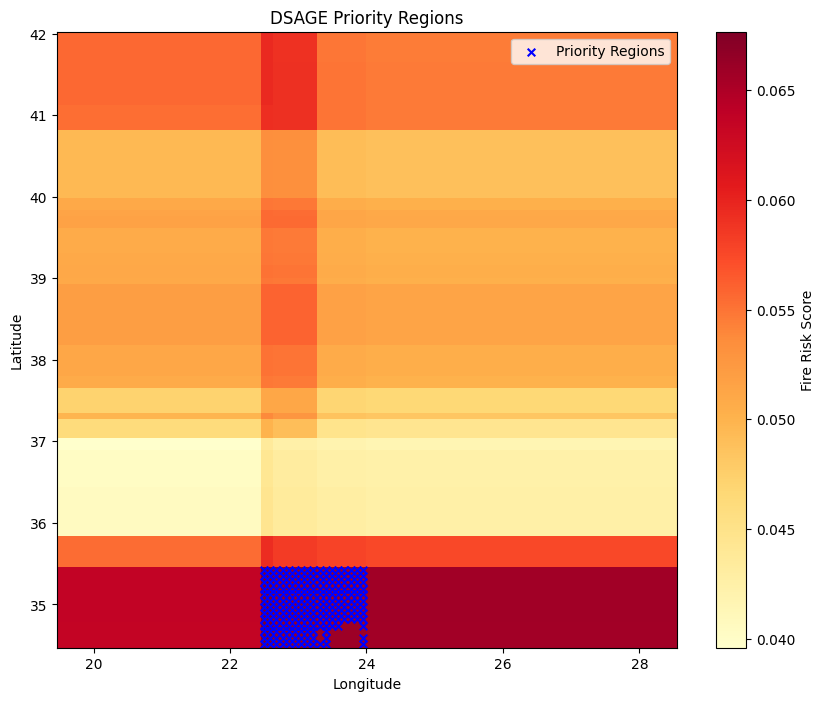

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestRegressor

class DSAGEOptimizer:
    def __init__(self, surrogate_batch_size=64):
        self.surrogate_model = None
        self.batch_size = surrogate_batch_size
        self.training_data = None
        self.training_labels = None

    def create_surrogate_model(self, input_dim):
        self.surrogate_model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
        print(f"Surrogate model created with input dimension {input_dim}")

    def train_surrogate(self, X, y):
        if self.surrogate_model is None:
            self.create_surrogate_model(X.shape[1])
        self.training_data = X
        self.training_labels = y
        print(f"Training surrogate model on {len(X)} samples...")
        self.surrogate_model.fit(X, y)
        score = self.surrogate_model.score(X, y)
        print(f"Surrogate model R² score: {score:.4f}")

    def optimize_datacube_processing(self, fire_events, feature_names, coords, sample_size=200):
        print("Optimizing datacube processing with DSAGE...")


        lats = coords['lats']
        lons = coords['lons']


        grid_size = min(100, len(lats), len(lons))
        lat_indices = np.linspace(0, len(lats)-1, grid_size, dtype=int)
        lon_indices = np.linspace(0, len(lons)-1, grid_size, dtype=int)

        sample_lats = lats[lat_indices]
        sample_lons = lons[lon_indices]

        LAT, LON = np.meshgrid(sample_lats, sample_lons)


        X = fire_events[feature_names].values


        y = fire_events['burned_area'].values
        y = (y - y.min()) / (y.max() - y.min())


        print("Training surrogate model on fire event data...")
        self.train_surrogate(X, y)


        print("Generating grid for risk prediction...")
        grid_points = []
        for i in range(len(sample_lats)):
            for j in range(len(sample_lons)):
                grid_points.append([
                    sample_lats[i],
                    sample_lons[j]
                ])


        feature_means = X.mean(axis=0)


        grid_features = np.tile(feature_means, (len(grid_points), 1))


        for i, (lat, lon) in enumerate(grid_points):

            grid_features[i, 0] += (lats.mean() - lat) * 0.1

            grid_features[i, 1] -= (lats.mean() - lat) * 0.05

            grid_features[i, 2] += (lons.mean() - lon) * 0.02


        print("Predicting fire risk across the region...")
        grid_probs = []
        for i in range(0, len(grid_features), self.batch_size):
            batch = grid_features[i:i+self.batch_size]
            batch_probs = self.surrogate_model.predict(batch)
            grid_probs.extend(batch_probs)

        grid_probs = np.array(grid_probs)


        risk_grid = grid_probs.reshape(len(sample_lats), len(sample_lons)).T


        num_priority = min(sample_size, len(grid_probs))
        priority_indices = np.argsort(grid_probs)[-num_priority:]
        priority_coords = np.array(grid_points)[priority_indices]

        print(f"Identified {len(priority_coords)} high-priority regions for focused analysis")
        return priority_coords, risk_grid, (LAT, LON)


print("Loading data for DSAGE optimization...")
try:

    fire_events = pd.read_csv('/content/mesogeos_results/fire_events.csv')
    print(f"Loaded {len(fire_events)} fire events")


    feature_importances = np.load('/content/mesogeos_results/feature_importances.npy', allow_pickle=True).item()
    feature_names = list(feature_importances.keys())
    print(f"Loaded feature importances for {feature_names}")


    try:
        coords = np.load('/content/mesogeos_results/coordinates.npy', allow_pickle=True).item()
    except:

        print("Coordinates not found, creating dummy coordinates")
        lats = np.linspace(34.5, 42.0, 744)
        lons = np.linspace(19.5, 28.5, 894)
        coords = {'lats': lats, 'lons': lons}


    optimizer = DSAGEOptimizer(surrogate_batch_size=64)
    priority_regions, risk_grid, grid_coords = optimizer.optimize_datacube_processing(
        fire_events, feature_names, coords, sample_size=200
    )


    os.makedirs('/content/mesogeos_results', exist_ok=True)
    np.save('/content/mesogeos_results/dsage_priority_regions.npy', priority_regions)
    np.save('/content/mesogeos_results/dsage_risk_grid.npy', risk_grid)
    np.save('/content/mesogeos_results/dsage_grid_coords.npy', grid_coords)

    print("DSAGE optimization complete and results saved")


    plt.figure(figsize=(10, 8))
    plt.pcolormesh(grid_coords[1], grid_coords[0], risk_grid, cmap='YlOrRd', shading='auto')
    plt.colorbar(label="Fire Risk Score")
    plt.scatter(priority_regions[:, 1], priority_regions[:, 0], c='blue',
                marker='x', s=30, label='Priority Regions')
    plt.title("DSAGE Priority Regions")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.savefig('/content/mesogeos_results/dsage_priority_regions.png')
    plt.show()

except Exception as e:
    print(f"Error in DSAGE optimization: {e}")
    import traceback
    traceback.print_exc()

## **5. Define and execute PhotoswapVisualizer with risk map and fire size composition map**

Loading data for Photoswap visualization...
Loaded 200 fire events
Loaded feature importances: {'t2m': np.float64(0.1580870776929044), 'rh': np.float64(0.15252709040640244), 'wind_speed': np.float64(0.14207569214749896), 'ndvi': np.float64(0.23198990653673018), 'smi': np.float64(0.31532023321646396)}
Most important feature: smi
Created attention mask based on smi


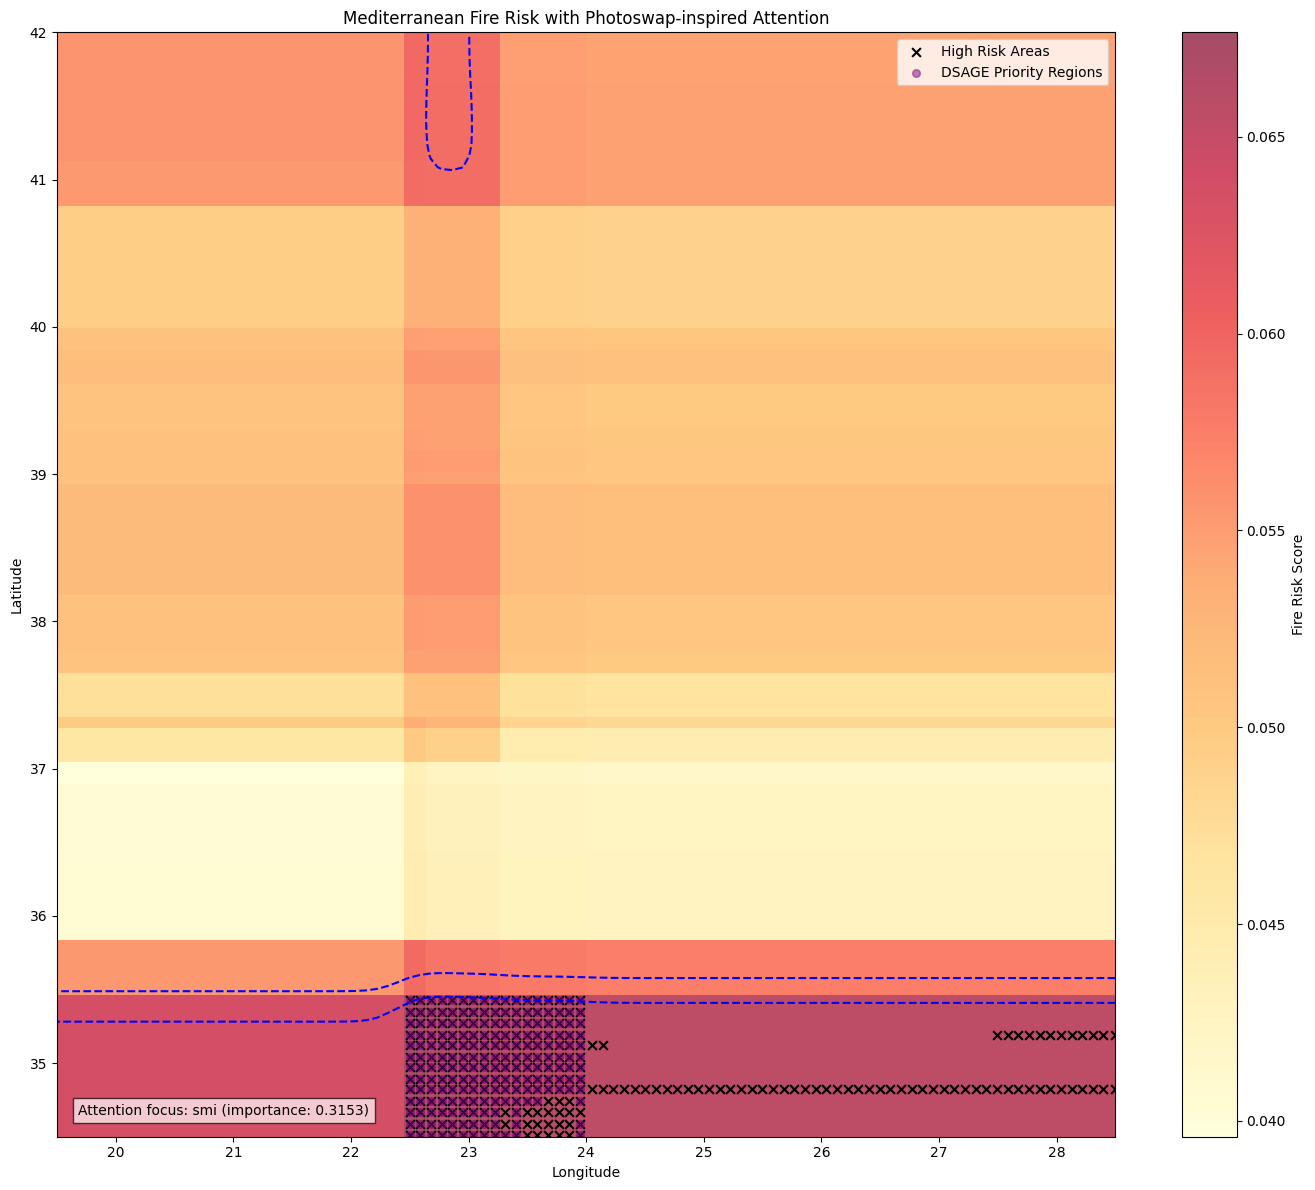

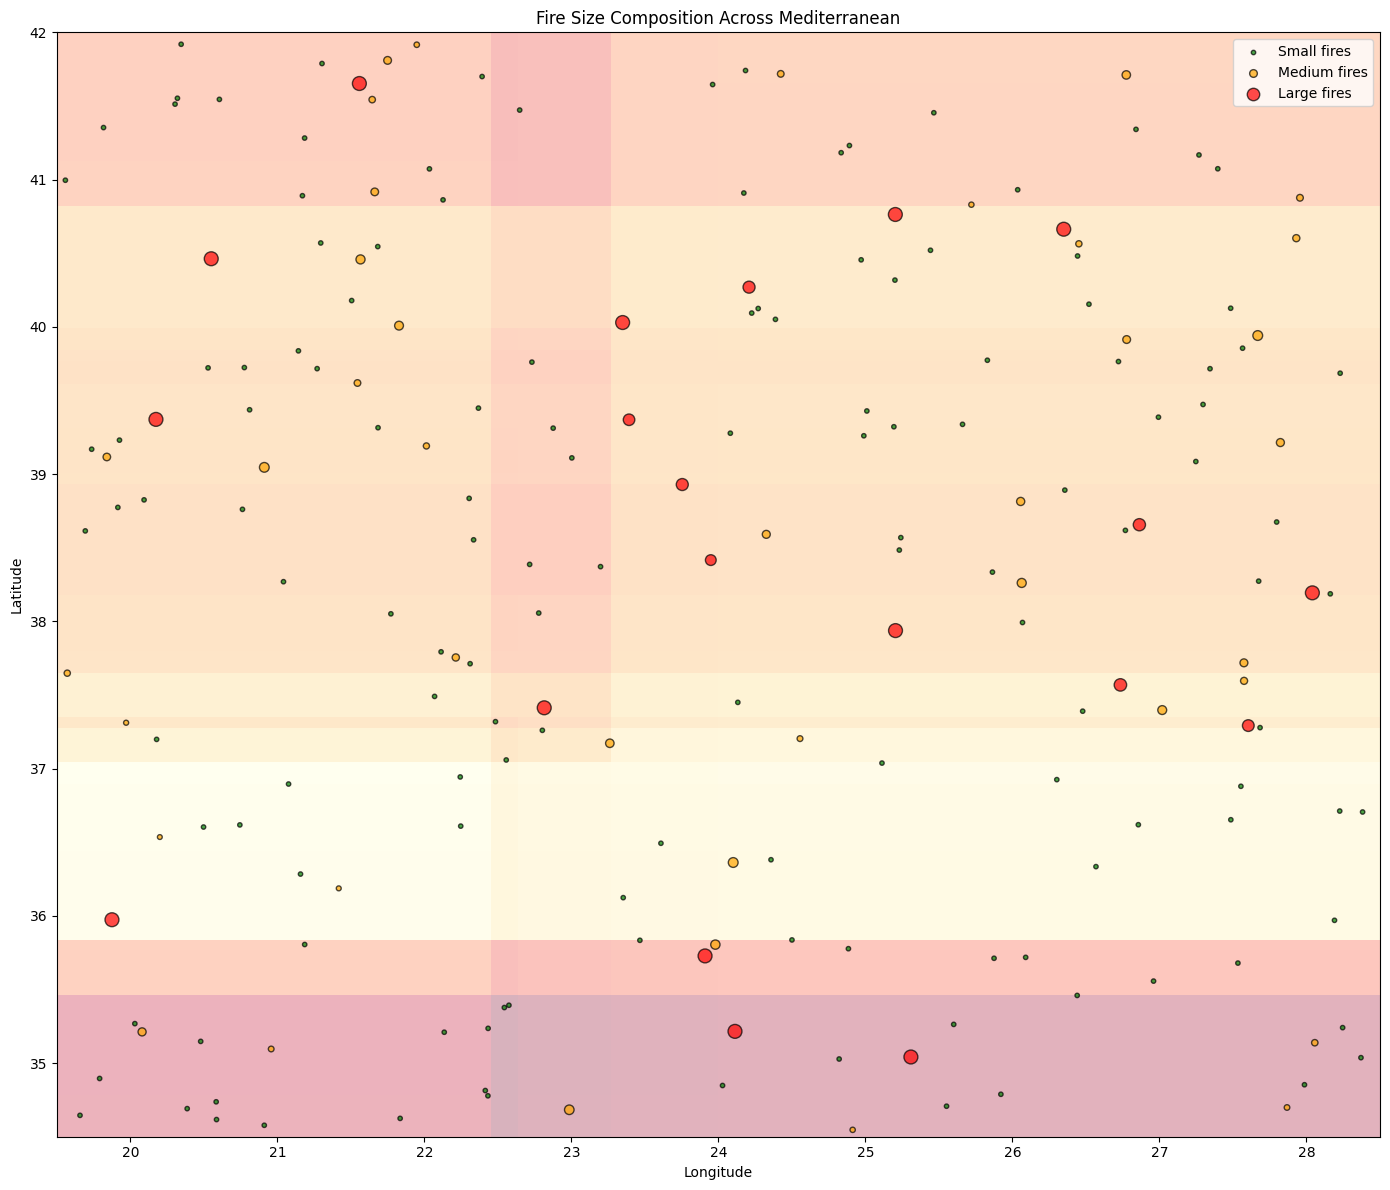

Photoswap-inspired visualizations complete and saved


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.ndimage import gaussian_filter

class PhotoswapVisualizer:

    def __init__(self, region_bounds=None):
        self.region_bounds = region_bounds
        self.fig_size = (14, 12)
        self.attention_cmap = plt.cm.Blues
        self.risk_cmap = plt.cm.YlOrRd

    def create_attention_mask(self, feature_importances, risk_grid, grid_coords):

        if not feature_importances:
            print("No feature importances available")
            return None, None, None


        try:

            important_feature = max(feature_importances.items(), key=lambda x: x[1])[0]
            importance_scores = list(feature_importances.values())
            normalized_scores = [score/sum(importance_scores) for score in importance_scores]

            print(f"Most important feature: {important_feature}")


            attention_mask = gaussian_filter(risk_grid, sigma=2)


            min_val = np.nanmin(attention_mask)
            max_val = np.nanmax(attention_mask)

            if max_val > min_val:
                attention_mask = (attention_mask - min_val) / (max_val - min_val)
            else:
                attention_mask = np.zeros_like(attention_mask)


            binary_mask = attention_mask > 0.7

            print(f"Created attention mask based on {important_feature}")
            return attention_mask, binary_mask, important_feature
        except Exception as e:
            print(f"Error creating attention mask: {e}")
            return None, None, None

    def plot_risk_map_with_attention(self, risk_grid, grid_coords, attention_mask, binary_mask, important_feature, feature_importances, title=None):

        plt.figure(figsize=self.fig_size)

        LAT, LON = grid_coords


        risk_plot = plt.pcolormesh(
            LON, LAT, risk_grid,
            cmap=self.risk_cmap,
            shading='auto',
            alpha=0.7
        )
        plt.colorbar(risk_plot, label='Fire Risk Score')


        if attention_mask is not None:

            contour = plt.contour(
                LON, LAT, attention_mask,
                levels=[0.7, 0.85],
                colors='blue',
                linewidths=1.5,
                linestyles='dashed'
            )


            high_risk = risk_grid > np.percentile(risk_grid, 95)
            high_risk_y, high_risk_x = np.where(high_risk)

            if len(high_risk_y) > 0:

                plt.scatter(
                    LON[high_risk_y, high_risk_x],
                    LAT[high_risk_y, high_risk_x],
                    c='black',
                    marker='x',
                    s=40,
                    label='High Risk Areas'
                )


            importance_value = feature_importances.get(important_feature, 0)
            plt.text(
                0.02, 0.02,
                f"Attention focus: {important_feature} (importance: {importance_value:.4f})",
                transform=plt.gca().transAxes,
                bbox=dict(facecolor='white', alpha=0.7)
            )


        try:
            priority_regions = np.load('/content/mesogeos_results/dsage_priority_regions.npy')
            if len(priority_regions) > 0:
                plt.scatter(
                    priority_regions[:, 1],
                    priority_regions[:, 0],
                    c='purple',
                    marker='o',
                    s=30,
                    alpha=0.5,
                    label='DSAGE Priority Regions'
                )
        except Exception as e:
            print(f"Could not load priority regions: {e}")

        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        if title is None:
            title = "Fire Risk Map with Photoswap-inspired Attention Visualization"
        plt.title(title)
        plt.legend(loc='upper right')

        if self.region_bounds:
            plt.xlim(self.region_bounds[0], self.region_bounds[1])
            plt.ylim(self.region_bounds[2], self.region_bounds[3])

        plt.tight_layout()
        return plt.gcf()

    def plot_fire_size_composition(self, fire_events, grid_coords, risk_grid, title=None):
        """
        Creates a visualization showing the composition of fire sizes across the region,
        inspired by Photoswap's ability to retain composition while swapping subjects.
        """
        plt.figure(figsize=self.fig_size)

        LAT, LON = grid_coords


        plt.pcolormesh(
            LON, LAT, risk_grid,
            cmap='YlOrRd',
            alpha=0.3,
            shading='auto'
        )


        colors = {'small': 'green', 'medium': 'orange', 'large': 'red'}


        size_column = 'fire_size'
        if size_column not in fire_events.columns:

            size_columns = [col for col in fire_events.columns if 'size' in col.lower()]
            if size_columns:
                size_column = size_columns[0]
            else:

                fire_events['fire_size'] = pd.cut(
                    fire_events['burned_area'],
                    bins=[0, 100, 500, float('inf')],
                    labels=['small', 'medium', 'large']
                )
                size_column = 'fire_size'


        fire_sizes = fire_events[size_column].unique()

        for size in fire_sizes:
            subset = fire_events[fire_events[size_column] == size]
            if len(subset) > 0:
                color = colors.get(size, 'blue') if size in colors else 'blue'


                if 'burned_area' in subset.columns:
                    sizes = subset['burned_area'] / 10
                    sizes = np.clip(sizes, 10, 100)
                else:
                    sizes = 30

                plt.scatter(
                    subset['longitude'],
                    subset['latitude'],
                    c=color,
                    label=f"{size.capitalize()} fires" if isinstance(size, str) else f"Size {size} fires",
                    alpha=0.7,
                    edgecolors='k',
                    s=sizes
                )

        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        if title is None:
            title = "Fire Size Composition with Photoswap-inspired Visualization"
        plt.title(title)
        plt.legend()

        if self.region_bounds:
            plt.xlim(self.region_bounds[0], self.region_bounds[1])
            plt.ylim(self.region_bounds[2], self.region_bounds[3])

        plt.tight_layout()
        return plt.gcf()


print("Loading data for Photoswap visualization...")
try:

    fire_events = pd.read_csv('/content/mesogeos_results/fire_events.csv')
    print(f"Loaded {len(fire_events)} fire events")


    feature_importances = np.load('/content/mesogeos_results/feature_importances.npy', allow_pickle=True).item()
    print(f"Loaded feature importances: {feature_importances}")


    risk_grid = np.load('/content/mesogeos_results/dsage_risk_grid.npy')
    grid_coords = np.load('/content/mesogeos_results/dsage_grid_coords.npy', allow_pickle=True)


    greece_bounds = (19.5, 28.5, 34.5, 42.0)
    visualizer = PhotoswapVisualizer(region_bounds=greece_bounds)


    attention_mask, binary_mask, important_feature = visualizer.create_attention_mask(
        feature_importances, risk_grid, grid_coords
    )


    risk_fig = visualizer.plot_risk_map_with_attention(
        risk_grid, grid_coords, attention_mask, binary_mask,
        important_feature, feature_importances,
        title="Mediterranean Fire Risk with Photoswap-inspired Attention"
    )


    os.makedirs('/content/mesogeos_results', exist_ok=True)
    risk_fig.savefig('/content/mesogeos_results/photoswap_risk_map.png')
    plt.show()


    comp_fig = visualizer.plot_fire_size_composition(
        fire_events, grid_coords, risk_grid,
        title="Fire Size Composition Across Mediterranean"
    )


    comp_fig.savefig('/content/mesogeos_results/photoswap_composition_map.png')
    plt.show()

    print("Photoswap-inspired visualizations complete and saved")

except Exception as e:
    print(f"Error in Photoswap visualization: {e}")
    import traceback
    traceback.print_exc()

## **6. Create and save 'requirements.txt'**.

In [ ]:
!pip freeze > /content/mesogeos_results/requirements.txt

print("Created requirements.txt file")

Created requirements.txt file
